In [2]:
pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# About Dataset
## EWOM → Electronic Word of Mouth
## ATSMA → Attitude toward Social Media Advertising
## PEER → Peer Influence
## PINT → Purchase Intention

In [4]:
df = pd.read_excel("dataset.xlsx", sheet_name="Participants Responses", header = 7)

In [5]:
df.head(10)

,Participant,Gender,Age,Domicile,Occupation,Which social media platform is most utilized to search for information about the local clothing product X?,E-WOM1,E-WOM2,E-WOM3,E-WOM4,...,ATSMA3,ATSMA4,PEER1,PEER2,PEER3,PEER4,PEER5,PINT1,PINT2,PINT3
0,1,Male,18-23,Jakarta,Student,Instagram,3,5,4,3,...,3,4,5,3,4,4,3,4,5,3
1,2,Male,18-23,Tangerang,Employee,Tiktok,3,4,3,4,...,5,3,4,3,1,4,4,3,3,4
2,3,Male,18-23,Jakarta,Student,Instagram,4,4,4,5,...,4,3,1,1,1,1,1,2,1,1
3,4,Male,18-23,Tangerang,Student,Tiktok,3,3,3,3,...,4,3,3,3,3,3,3,3,3,3
4,5,Male,18-23,Tangerang,Student,Tiktok,4,3,3,3,...,4,3,3,3,3,4,3,3,3,3
5,6,Male,18-23,Jakarta,Student,Tiktok,3,4,5,3,...,5,4,5,5,3,4,4,5,4,3
6,7,Male,18-23,Jakarta,Student,Instagram,3,3,3,4,...,4,3,3,3,3,3,3,3,3,3
7,8,Male,24-28,Jakarta,Employee,Instagram,4,5,4,5,...,4,5,5,4,5,4,5,5,4,5
8,9,Female,24-28,Tangerang,Entrepreneur,Instagram,4,3,4,3,...,4,5,3,2,1,1,1,3,4,4
9,10,Female,24-28,Tangerang,Unemployment,Instagram,3,4,4,4,...,5,4,3,4,4,5,3,5,1,5


# Calculating Mean Scores across Columns

In [6]:
e_wom_cols = ['E-WOM1','E-WOM2','E-WOM3','E-WOM4']
df['E-WOM_score'] = df[e_wom_cols].mean(axis=1)

In [7]:
atsma_cols = ['ATSMA1','ATSMA2','ATSMA3','ATSMA4']
df['ATSMA_score'] = df[atsma_cols].mean(axis=1)

In [8]:
peer_cols = ['PEER1','PEER2','PEER3','PEER4']
df['PEER_score'] = df[peer_cols].mean(axis=1)

In [9]:
pint_cols = ['PINT1','PINT2','PINT3']
df['PINT_score'] = df[pint_cols].mean(axis=1)

# Checking the consistency across questions

In [10]:
def cronbach_alpha(df_subset):
    df_corr = df_subset.corr()
    n = len(df_subset.columns)
    avg_corr = df_corr.values[np.triu_indices(n, 1)].mean()
    return (n * avg_corr) / (1 + (n - 1) * avg_corr)

cronbach_alpha(df[e_wom_cols])

np.float64(0.8411363893187089)

In [11]:
def cronbach_alpha(df_subset):
    df_corr = df_subset.corr()
    n = len(df_subset.columns)
    avg_corr = df_corr.values[np.triu_indices(n, 1)].mean()
    return (n * avg_corr) / (1 + (n - 1) * avg_corr)

cronbach_alpha(df[atsma_cols])

np.float64(0.7637962762148541)

In [12]:
def cronbach_alpha(df_subset):
    df_corr = df_subset.corr()
    n = len(df_subset.columns)
    avg_corr = df_corr.values[np.triu_indices(n, 1)].mean()
    return (n * avg_corr) / (1 + (n - 1) * avg_corr)

cronbach_alpha(df[peer_cols])

np.float64(0.9077814610443043)

In [13]:
def cronbach_alpha(df_subset):
    df_corr = df_subset.corr()
    n = len(df_subset.columns)
    avg_corr = df_corr.values[np.triu_indices(n, 1)].mean()
    return (n * avg_corr) / (1 + (n - 1) * avg_corr)

cronbach_alpha(df[pint_cols])

np.float64(0.8341535126776302)

# ATSMA Vs PINT 

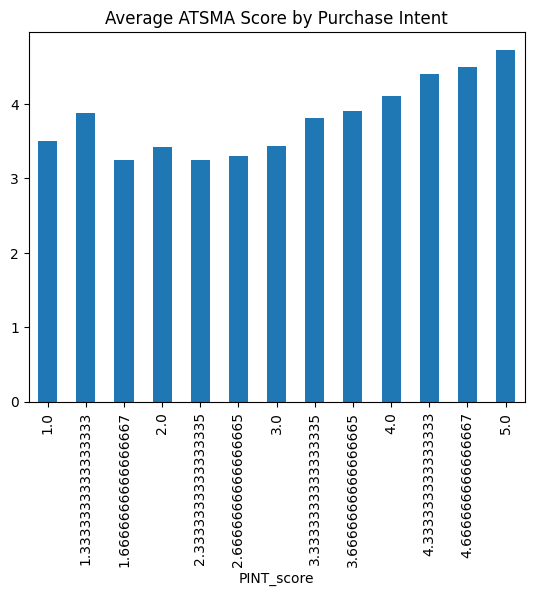

In [15]:
avg_scores = df.groupby('PINT_score')['ATSMA_score'].mean()
avg_scores.plot.bar()
plt.title("Average ATSMA Score by Purchase Intent")
plt.show()

# Correlation between features

In [16]:
df[['ATSMA_score', 'PEER_score', 'E-WOM_score', 'PINT_score']].corr()

,ATSMA_score,PEER_score,E-WOM_score,PINT_score
ATSMA_score,1.000000,0.474637,0.588338,0.635182
PEER_score,0.474637,1.000000,0.522526,0.670231
E-WOM_score,0.588338,0.522526,1.000000,0.567178
PINT_score,0.635182,0.670231,0.567178,1.000000


# Converting PINT score into binary

In [17]:
def convert_intent(x):
    if x>=3.5:
        return 1
    else:
        return 0
    
df['purchase_intent'] = df['PINT_score'].apply(convert_intent)    

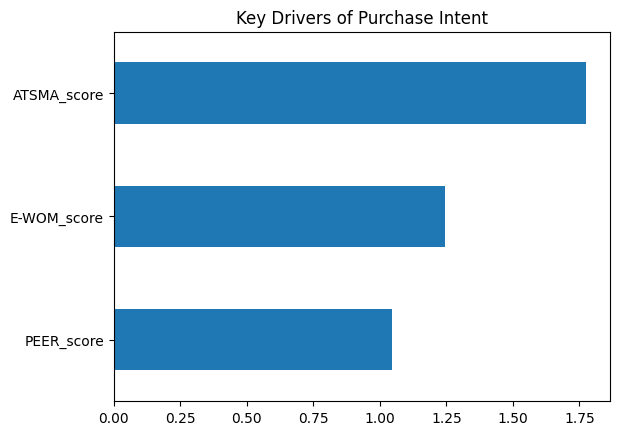

In [18]:
from sklearn.linear_model import LogisticRegression

X = df[['ATSMA_score','E-WOM_score','PEER_score']]
y = df['purchase_intent']

model = LogisticRegression()
model.fit(X, y)

importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Key Drivers of Purchase Intent")
plt.show()

# Customer Segmentation

In [19]:
from sklearn.cluster import KMeans

features = df[['ATSMA_score','E-WOM_score','PEER_score']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['segment'] = kmeans.fit_predict(features)

In [20]:
df.groupby('segment')[['ATSMA_score','E-WOM_score','PEER_score']].mean()

,ATSMA_score,E-WOM_score,PEER_score
segment,,,
0,4.348837,4.290698,4.255814
1,3.387097,3.213710,3.221774
2,3.796875,3.429688,1.835938


In [21]:
segment_map = {
    0: "Highly Influenced Buyers",
    1: "Independent Buyers",
    2: "Peer-Driven Buyers"
}

df['segment_label'] = df['segment'].map(segment_map)

In [22]:
df['segment_label']

0      Highly Influenced Buyers
1            Independent Buyers
2            Peer-Driven Buyers
3            Independent Buyers
4            Independent Buyers
                 ...           
175    Highly Influenced Buyers
176    Highly Influenced Buyers
177          Peer-Driven Buyers
178          Independent Buyers
179          Independent Buyers
Name: segment_label, Length: 180, dtype: str

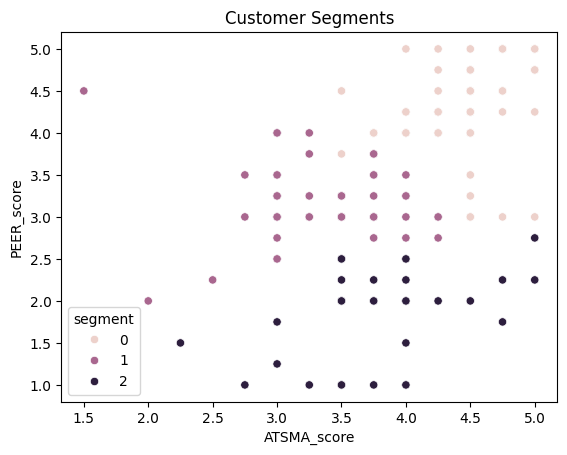

In [23]:
sns.scatterplot(x='ATSMA_score', y='PEER_score', hue='segment', data=df)
plt.title("Customer Segments")
plt.show()